In [1]:
import matplotlib.pyplot as plt
import PcmPy as pcm
# from vis import save_figure_incremental, make_axes_square
import os
import globals as gl
import pickle
import numpy as np
from pcm_cortical import make_planning_models, make_execution_models, find_model, normalize_Ac



plt.style.use('default')
# plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


ImportError: cannot import name 'make_planning_models' from 'pcm_cortical' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/pcm_cortical.py)

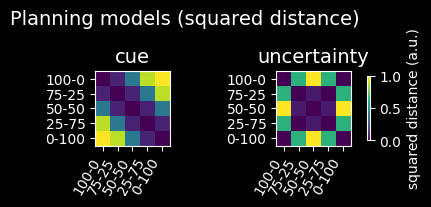

In [3]:
experiment = 'smp2'

M = make_planning_models()

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G / np.trace(m.G)))
        G.append(m.G)
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), figsize=(4, 2), constrained_layout=True)

for i, (g, d, n) in enumerate(zip(G, D, name)):
    cax = axs[i].imshow(d, vmin=0, vmax=1, )
    axs[i].set_title(n, fontsize=14, )
    axs[i].set_xticks(np.arange(5))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=60, ha='right')
    axs[i].set_yticks(np.arange(5))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=0, ha='right')

fig.suptitle('Planning models (squared distance)', fontsize=14,)
fig.tight_layout()

# Add a single colorbar for the entire figure
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=0.01)
cbar.set_label("squared distance (a.u.)")

plt.show()



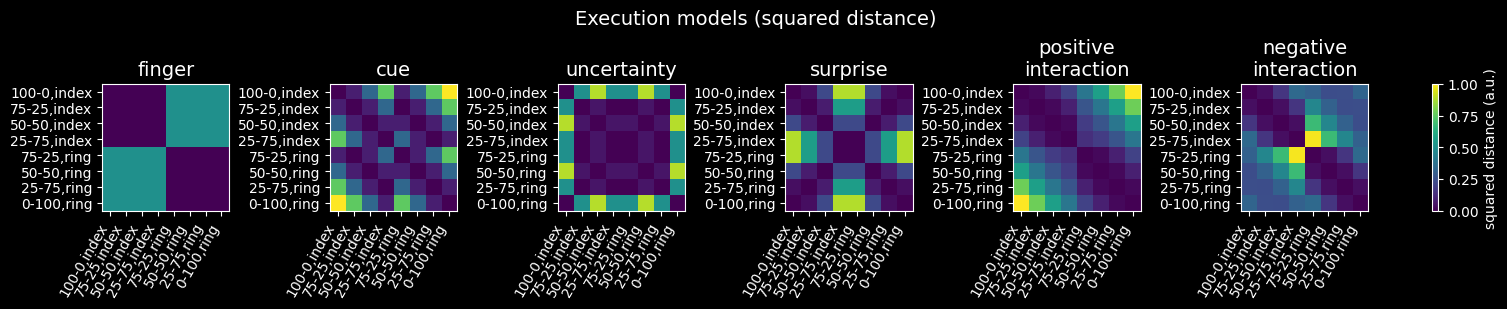

In [9]:
experiment = 'smp2'

M = make_execution_models(centering=True)

D,  name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'planning force'):
        D.append(pcm.G_to_dist(m.G / np.trace(m.G)))
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        Ac_pos = (m.Ac * np.array([1, 1, 1,])[:, None, None]).sum(axis=0)
        Gx_pos = Ac_pos @ Ac_pos.T
        Ac_neg = (m.Ac * np.array([1, 1, -1,])[:, None, None]).sum(axis=0)
        Gx_neg = Ac_neg @ Ac_neg.T
        D.append(pcm.G_to_dist(Gx_pos / np.trace(Gx_pos)))
        D.append(pcm.G_to_dist(Gx_neg / np.trace(Gx_neg)))
        name.append('positive\ninteraction')
        name.append('negative\ninteraction')

# Set vmin and vmax values for all images
vmin, vmax = 0, 1

fig, axs = plt.subplots(1, len(D), figsize=(15, 3), constrained_layout=True)

for i, ( d, n) in enumerate(zip(D, name)):
    im = axs[i].imshow(d, vmin=vmin, vmax=vmax)
    axs[i].set_title(n, fontsize=14)

    axs[i].set_xticks(np.arange(8))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=60, ha='right')
    axs[i].set_yticks(np.arange(8))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[5:13], ha='right')

# Add a single colorbar for the entire figure
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.005)
cbar.set_label("squared distance (a.u.)")

fig.suptitle('Execution models (squared distance)', fontsize=14)

plt.show()